# 🔬 EDA: IMU Footprint of Impact Angle

**Goal**: Visually prove that `impact_angle` (continuous, 20°–88°) leaves a distinct, measurable footprint in the drone's high-frequency IMU data.

**Scope**: Both **Fixed Cage** and **Rotating Cage** collisions (70 + 60 flights with verified impacts). The two cage types produce fundamentally different collision physics and are analyzed side by side.

**Method**: Pearson correlation matrix + targeted scatter plots with robust Huber trendlines + RandomForestRegressor.

**Output**: All figures saved to `graphics/` for thesis inclusion.

In [1]:
%matplotlib inline
# ── Dynamic Path Header ────────────────────────────────────────────
import sys, os
# Notebook is in dev_logs/analysis/, so go up 2 levels to project root
project_root = os.path.abspath(os.path.join(os.path.abspath(""), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from dev_logs.analysis.eda.eda_angle_prediction import (
    load_impact_data,
    plot_correlation_heatmap,
    plot_top3_scatter,
    plot_parallel_coordinates,
    plot_consolidated_parallel_coordinates,
    plot_consolidated_feature_correlation,
    plot_consolidated_top_features,
    huber_regressor,
    CONDITION_COLORS,
    IMU_COLS,
    DISPLAY_NAMES,
    FEATURE_GROUPS,
    GROUP_COLORS,
    GRAPHICS_DIR,
)

from dev_logs.analysis.models.rf_angle_prediction import (
    run_rf_pipeline,
    generate_consolidated_plots,
)

# Professional plotting style (thesis)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'figure.titlesize': 14,
    'figure.dpi': 150,
})

/home/dorten/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Data Loading & Quality Check

Load both **Fixed Cage** and **Rotating Cage** flights with `impact_detected == 1`. All 26 IMU columns and `impact_angle` are checked for completeness. Flights with any NaN in these columns are dropped.

The two cage types produce fundamentally different collision physics and are analyzed side by side throughout — **every figure in this notebook shows both conditions in a single consolidated layout** (Rotating Cage on the left, Fixed Cage on the right).

📡 Loading flight data from SQLite database...
   → 67 Fixed Cage impact flights found (out of 168 total).
   → 67 flights with complete IMU data after dropping NaN rows.
   → impact_angle range: [19.8°, 87.9°]
   → battery_at_start range: [15.0%, 98.3%]
📊 DataFrame shape: (67, 28)
   → 67 flights × 28 columns


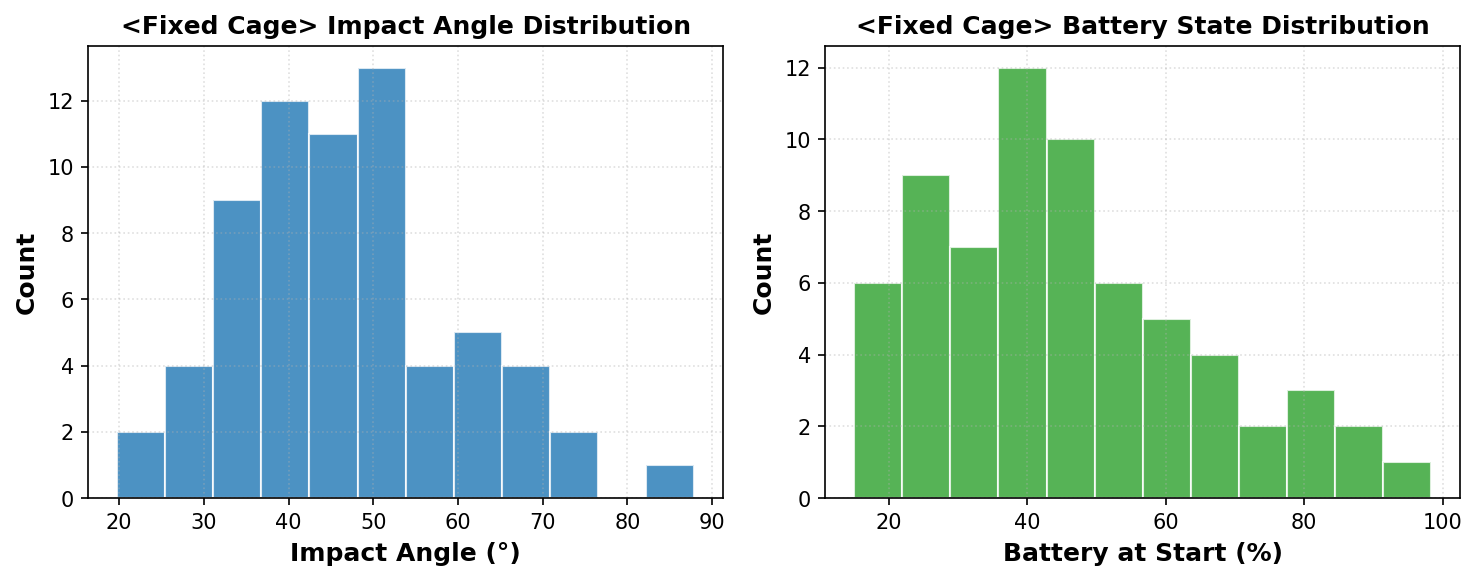

In [2]:
df_fix = load_impact_data(condition='Fixed Cage')
print(f"📊 DataFrame shape: {df_fix.shape}")
print(f"   → {len(df_fix)} flights × {len(df_fix.columns)} columns")

# Quick histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

ax1.hist(df_fix['impact_angle'], bins=12, color='#1F77B4', edgecolor='white', alpha=0.8)
ax1.set_xlabel('Impact Angle (°)', fontweight='bold')
ax1.set_ylabel('Count', fontweight='bold')
ax1.set_title('<Fixed Cage> Impact Angle Distribution', fontweight='bold', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.4)

ax2.hist(df_fix['battery_at_start'], bins=12, color='#2CA02C', edgecolor='white', alpha=0.8)
ax2.set_xlabel('Battery at Start (%)', fontweight='bold')
ax2.set_ylabel('Count', fontweight='bold')
ax2.set_title('<Fixed Cage> Battery State Distribution', fontweight='bold', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

### Rotating Cage

📡 Loading flight data from SQLite database...
   → 60 Rotating Cage impact flights found (out of 168 total).
   → 60 flights with complete IMU data after dropping NaN rows.
   → impact_angle range: [16.8°, 68.9°]
   → battery_at_start range: [15.3%, 92.2%]
📊 DataFrame shape: (60, 28)
   → 60 flights × 28 columns


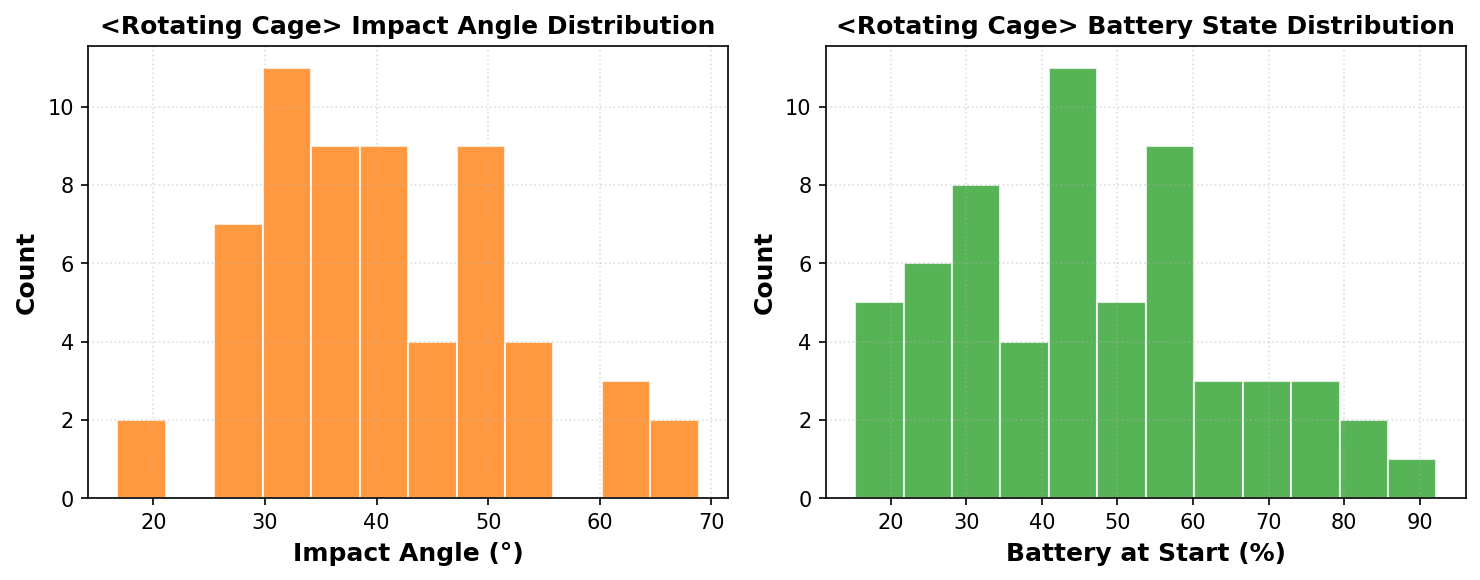

In [3]:
df_rot = load_impact_data(condition='Rotating Cage')
print(f"📊 DataFrame shape: {df_rot.shape}")
print(f"   → {len(df_rot)} flights × {len(df_rot.columns)} columns")

# Quick histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

ax1.hist(df_rot['impact_angle'], bins=12, color='#FF7F0E', edgecolor='white', alpha=0.8)
ax1.set_xlabel('Impact Angle (°)', fontweight='bold')
ax1.set_ylabel('Count', fontweight='bold')
ax1.set_title('<Rotating Cage> Impact Angle Distribution', fontweight='bold', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.4)

ax2.hist(df_rot['battery_at_start'], bins=12, color='#2CA02C', edgecolor='white', alpha=0.8)
ax2.set_xlabel('Battery at Start (%)', fontweight='bold')
ax2.set_ylabel('Count', fontweight='bold')
ax2.set_title('<Rotating Cage> Battery State Distribution', fontweight='bold', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

### Dataset Used

| Property | Value |
|---|---|
| **Source** | `flights_summary` in `experiments_summary.db` (via `get_database_df()`) |
| **Conditions** | Fixed Cage (67 flights) + Rotating Cage (60 flights) — analyzed side by side |
| **Filters** | `impact_detected == 1`, `excluded == 0` |
| **Flight approval** | Only flights $\geq$ `20260524-1904` (poor MoCap tracking before) |
| **IMU columns** | 26 aggregate metrics — peak accel/gyro, integrated energy, vibration, settling time, accel spread |
| **NaN handling** | Any flight with NaN in selected IMU columns or `impact_angle` is dropped |

**Pass selection:** Each row is one collision pass from a flight. Multiple passes per
flight are treated as independent observations (the drone returns to setpoint between
passes, which resets the collision dynamics).

## 2. IMU Feature Correlation with Impact Angle

**What we're measuring:** Pearson *r* between each of the 26 IMU aggregate metrics and `impact_angle`. The correlation coefficient ranges from −1 (perfect negative linear relationship) to +1 (perfect positive), with 0 meaning no linear relationship.

**Layout — mirrored slopegraph with integrated heatmaps:**

The figure uses a 5-column `GridSpec` to track how feature ranks change between cage types:

| Column | Content |
|--------|---------|
| **Rotating Keys** | Rank number + feature name, sorted by Rotating |*r*|, left-aligned |
| **Rotating Heatmap** | 1-column heatmap with *r* values annotated inside each cell |
| **Splines** | Curved `ConnectionPatch` arcs tracing each feature between cages |
| **Fixed Heatmap** | 1-column heatmap with *r* values annotated inside each cell |
| **Fixed Keys** | Feature name only (no rank), right-edge, left-aligned outward |

**How to read the splines:**
- A **straight horizontal** line → the feature has the same rank in both cages
- A **steep diagonal** → rank reordering between configurations (thicker, more opaque lines)
- **Red splines** → large rank shifts (≥4 positions) between cage types
- **Grey splines** → stable ranks (≤3 positions difference)

The vertical ordering in each column is independent — Row 1 is always the highest |*r*| feature *for that cage*. This means a feature appearing at position 3 on the left and position 7 on the right visually signals that it is a strong correlate in Rotating but weaker in Fixed.

**Significance:** Cells are annotated with standard significance stars (*** p<0.001, ** p<0.01, * p<0.05).

   💾 Saved consolidated feature correlation → ../graphics/consolidated_feature_correlation.png
   📎 → thesis/plots/consolidated_feature_correlation.png


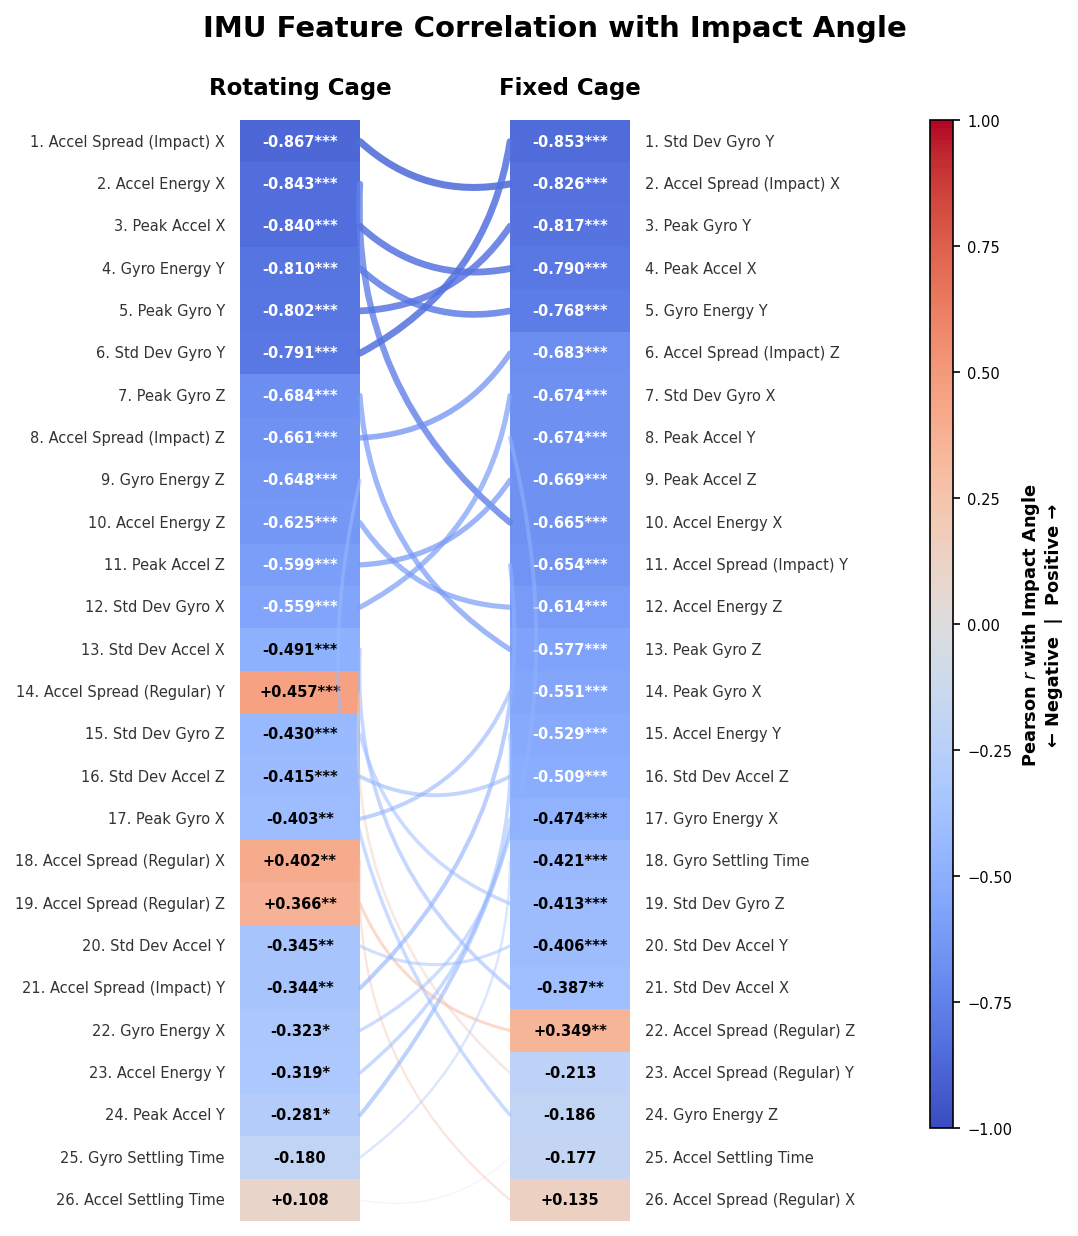

In [4]:
# ── Consolidated Feature Correlation (GridSpec + ConnectionPatch) ──
from dev_logs.analysis.eda.eda_angle_prediction import (
    plot_consolidated_feature_correlation, CONDITION_COLORS,
)

plot_consolidated_feature_correlation(
    df_fix, df_rot,
    save_path=os.path.join(GRAPHICS_DIR, "consolidated_feature_correlation.png"),
    show=True,
)


### Key Observations — Feature Correlation

The mirrored slopegraph reveals several patterns that a standalone heatmap would miss:

1. **Rank stability vs. reordering:** Features with grey horizontal splines (e.g., top vibration metrics) maintain similar importance in both cage types. Features with red diagonal splines shift dramatically — their predictive value depends on whether the cage is spinning.

2. **Negative correlation dominance:** Nearly all significant correlations are negative — meaning lower IMU readings correspond to steeper (more perpendicular) impact angles. Physically, a grazing impact (~20°) transfers more rotational energy to the drone than a head-on hit (~90°), producing higher gyro rates and acceleration magnitudes.

3. **Spread metrics outrank raw peaks:** `Accel Spread (Impact)` features — which capture variability during the impact window rather than instantaneous max values — tend to rank higher than `Peak Accel` features. The *character* of the impact (how chaotic the acceleration profile is) matters more than the *magnitude* of the hardest hit.

4. **Gyro axes dominate in both cages:** Vibration Gyro Y (pitch-axis rotational vibration) is consistently among the top-ranked features. The pitch axis is the one that rotates *into* the column — a shallow-angle collision torques the drone around pitch much more than a perpendicular strike.

5. **Rotating Cage has fewer highly significant correlations:** Compare the density of significance stars between the left and right heatmaps. The Fixed Cage generally shows stronger, more significant Pearson *r* values — the rotating cage's additional degrees of freedom add noise that dilutes individual feature correlations.

## 3. Top IMU Features vs. Impact Angle

**Feature selection:** The **top 3** IMU features by |Pearson *r*| are selected **independently** for each cage. The left column shows the Rotating Cage's own top 3; the right column shows the Fixed Cage's own top 3. `imu_ax_spread_impact` is forced to Row 1 in both columns for direct visual comparison.

**Layout:** 4-row GridSpec — Row 0 is a centered 2-column Pearson *r* heatmap reference spanning both columns; Rows 1–3 are scatter plot pairs (Rotating left, Fixed right). Both columns carry Y-axis labels with ordinal rank + feature name.

**Trendline:** Robust Huber M-estimator (δ = 1.345) — resists outlier pull from anomalous flights without discarding them.

**Coloring:** Points colored by `battery_at_start` (viridis colormap) to visually check whether battery state confounds the feature–angle relationship.

**Hardcoded y-limits** (where applicable):

| Feature | Y-Range | Tick Step |
|---------|---------|-----------|
| Accel Spread (Impact) X/Y/Z | [0, 0.5] | 0.1 |
| Accel Energy X/Y/Z | [0, 1.0] | 0.2 |
| Peak Accel X/Y/Z | [0, 20] | 4.0 |
| Vibration Gyro X/Y/Z | [0, 0.30] | 0.06 |

These limits are identical for both cages so the visual comparison is fair — if a feature's range differs between conditions, the fixed y-axis makes it immediately apparent.

   💾 Saved consolidated top features → ../graphics/consolidated_top_features.png


   📎 → thesis/plots/consolidated_top_features.png


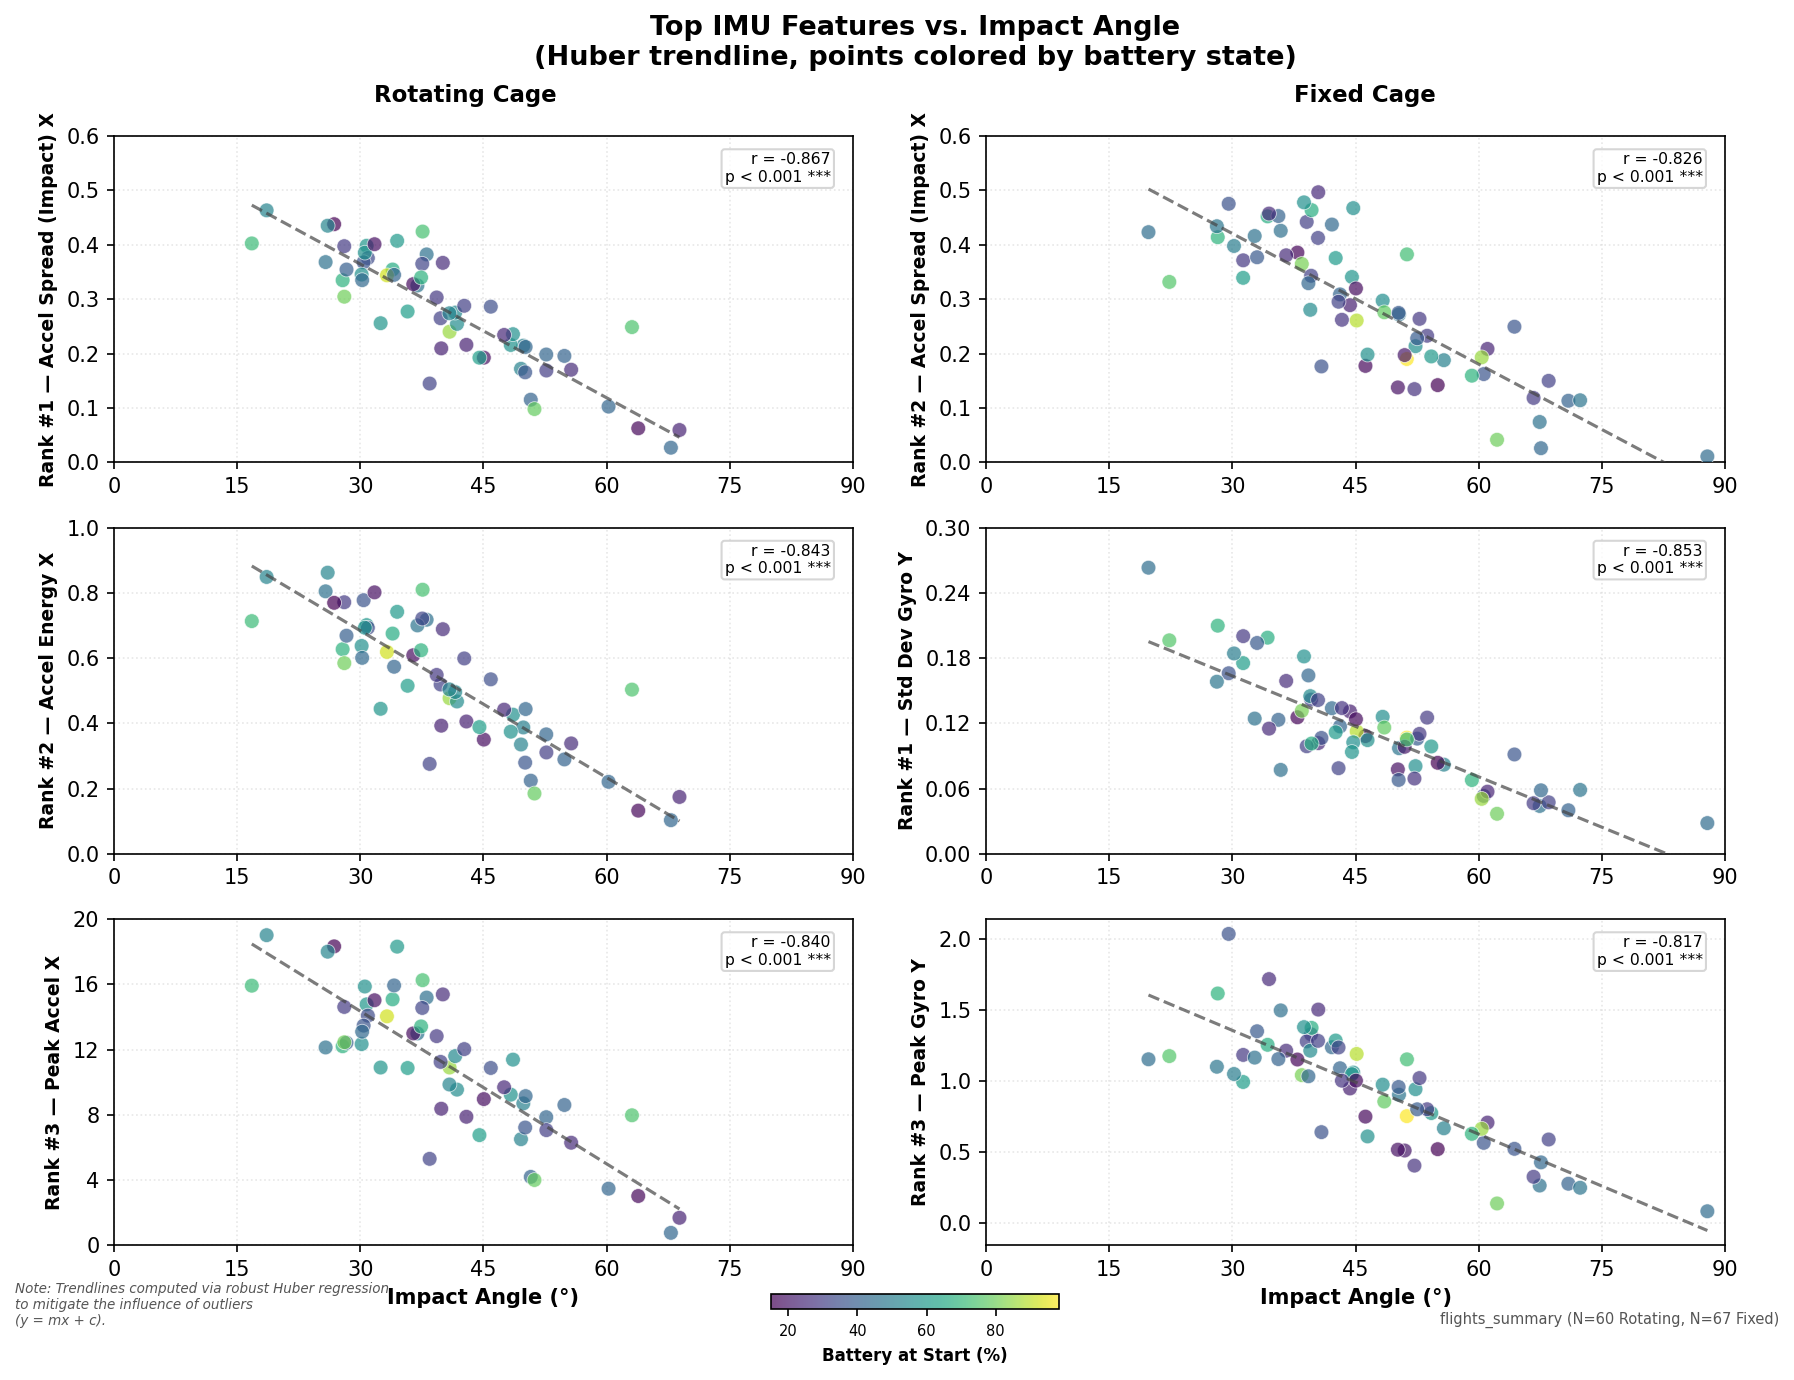

In [5]:
# ── Consolidated Top Features (both cages side-by-side) ──
plot_consolidated_top_features(
    df_fix, df_rot,
    save_path=os.path.join(GRAPHICS_DIR, "consolidated_top_features.png"),
    show=True,
)


### Key Observations — Top Features

1. **Accel Spread (Impact) X dominates both cages.** With r ≈ −0.87 (Rotating) and r ≈ −0.83 (Fixed), it is the strongest individual predictor of impact angle. The negative correlation means steeper impacts produce less chaotic X-axis acceleration during the collision window — physically intuitive: a head-on hit has a cleaner, shorter acceleration profile than a grazing strike.

2. **Beyond Row 1, the cages diverge.** Rotating Cage's top features are all surge-axis (Accel Energy X, Peak Accel X) — the spinning cage channels energy along the drone's forward axis. Fixed Cage's top features shift to rotational metrics (Vibration Gyro Y, Peak Gyro Y) — without the spinning cage, the pitch-axis rotational disturbance becomes the dominant signal.

3. **The Huber trendlines confirm direction and rough linearity.** All three features show clear negative slopes in both cages, but the scatter around the trendline is substantial — single-feature linear models would leave wide prediction intervals. This is why the Random Forest (§5) is needed.

4. **Fixed Cage scatter shows tighter clustering.** Compare the point spread between left and right columns for the same feature. The rotating cage's additional mechanical degrees of freedom (gyroscopic precession) widen the scatter, reducing individual feature correlations.

5. **Battery state does not visually confound the relationship.** The viridis colors appear well-mixed across the scatter, suggesting `battery_at_start` is not a hidden driver of the observed correlations.

## 4. Parallel Coordinates

Multi-dimensional view with both cage conditions in a single 2×1 figure.

Features are ranked by |Pearson *r*| against impact_angle (computed on the **combined** dataset so ordering is identical for both panels).

**Updated format:**
• Rank numbers (1st, 2nd, …) placed **under** each tick label on the X-axis
• X-axis margins removed — data lines extend full width edge-to-edge
• Reduced vertical padding between super-title and subplot titles
• Each polyline is min-max normalized to [0, 1] and colored by angle group

   💾 Saved consolidated parallel coordinates → ../graphics/consolidated_parallel_coordinates.png


   📎 → thesis/plots/consolidated_parallel_coordinates.png


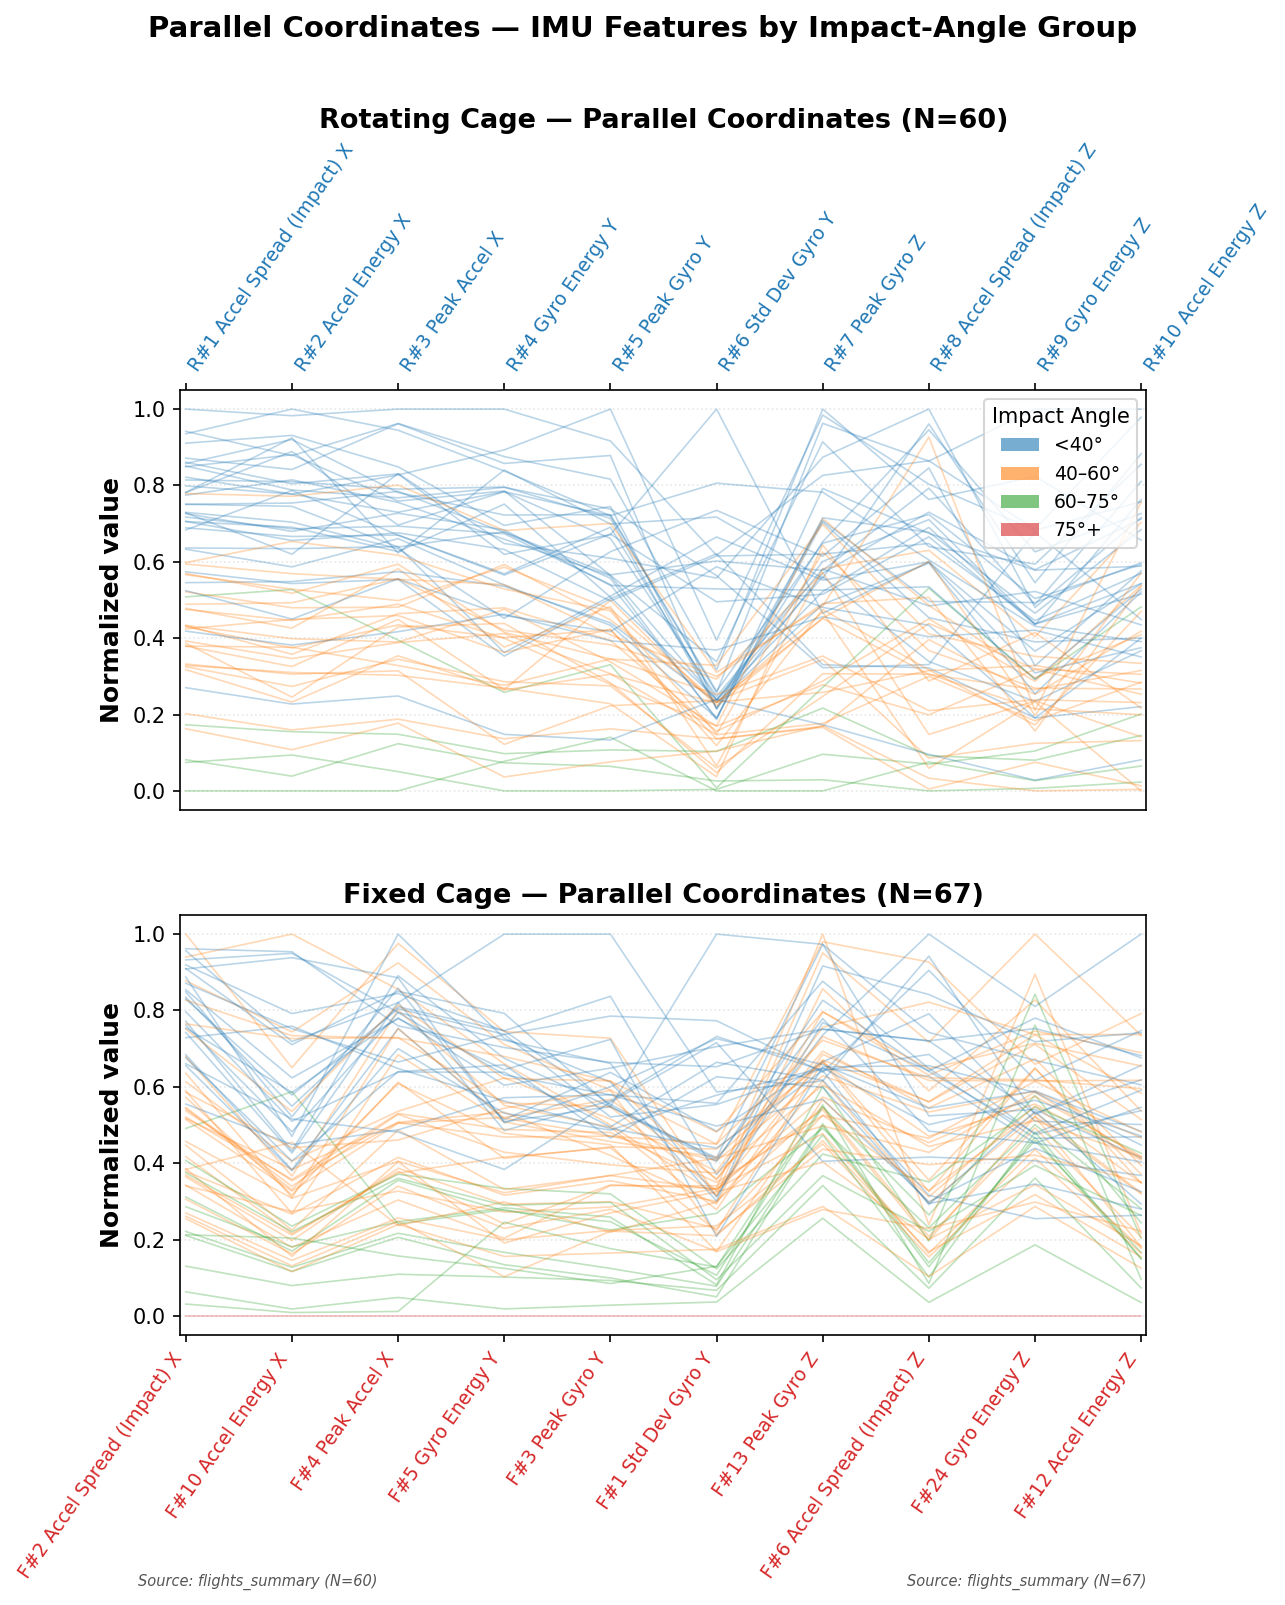

In [6]:
plot_consolidated_parallel_coordinates(
    df_fix, df_rot,
    save_path=os.path.join(GRAPHICS_DIR, "consolidated_parallel_coordinates.png"),
    show=True
)

### Key Observations — Parallel Coordinates

1. **No clear angle-group separation.** Unlike what a clean physical model would predict, the polylines for different angle bins (<40°, 40–60°, 60–75°, 75°+) do not form visually distinct clusters. This confirms the relationship between IMU features and impact angle is **multivariate and non-linear** — no single feature axis cleanly splits the angle groups.

2. **Rotating Cage shows more overlap than Fixed Cage.** The additional mechanical degrees of freedom in the rotating condition smear the polylines further, making angle groups even harder to distinguish by eye.

3. **The Random Forest earns its keep here.** If parallel coordinates showed clear separation, a simple linear discriminant would suffice. The fact that they don't justifies the non-linear, multi-feature approach in §5–§8.

4. **Feature ordering is consistent across cages.** The ranking (by combined |Pearson *r*|) places the same features at the top regardless of cage type, even though their individual correlation strengths differ.

## 5. RandomForestRegressor — Fixed Cage

Training on Fixed Cage collisions, testing on Rotating Cage for cross-condition transfer.
The pipeline includes: feature selection (correlation + redundancy filter), nested 5-fold CV with grid search over `max_depth × min_samples_leaf`, and a Huber linear baseline for comparison.

In [7]:
# ── Ensure sklearn is available (fallback for kernel issues) ──
import subprocess, sys
try:
    import sklearn
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-learn'])
    import sklearn

# ── Import the RF pipeline ─────────────────────────────────────────────
# Re-import needed: the module may have changed since first load
import importlib
import dev_logs.analysis.models.rf_angle_prediction as rf_mod
importlib.reload(rf_mod)
from dev_logs.analysis.models.rf_angle_prediction import run_rf_pipeline

# ⚠️  show_plots=False — individual per-cage plots are superseded by
#     the consolidated comparison figures in §8 below.
# Pass the universal dataframes from §1 so the pipeline uses the same data
# as every other plot in this notebook (SSoT enforcement).
results_fix = run_rf_pipeline(train_condition='Fixed Cage', save_to_disk=True,
                               show_plots=False, df_train=df_fix, df_transfer=df_rot)

🌲 RandomForestRegressor: Impact Angle Prediction Pipeline <Fixed Cage>
📊 Using pre-loaded dataframes: 67 Fixed Cage + 60 Rotating Cage impact flights.
   → 67 Fixed Cage flights with complete IMU data

🔍 Feature Selection (|r| or |ρ| > 0.3, redundancy cutoff r > 0.85):
   Candidate pool: 26 IMU features
   Pass correlation filter: 23 features
   Removed 9 redundant (pairwise r > 0.85):
      ✂  Accel Energy Z
      ✂  Peak Accel Z
      ✂  Accel Energy Y
      ✂  Accel Spread (Impact) Z
      ✂  Peak Gyro Y
      ✂  Accel Energy X
      ✂  Gyro Energy Y
      ✂  Gyro Energy X
      ✂  Peak Accel X
   ✅ Final feature set: 14 features
      Peak Accel Y                    r = -0.6738
      Peak Gyro X                     r = -0.5514
      Peak Gyro Z                     r = -0.5774
      Std Dev Accel X                 r = -0.3870
      Std Dev Accel Y                 r = -0.4064
      Std Dev Accel Z                 r = -0.5089
      Std Dev Gyro X                  r = -0.6745
      Std

   depth=3, leaf= 3  → R² = 0.6929 ± 0.1005


   depth=3, leaf= 5  → R² = 0.6910 ± 0.0852


   depth=3, leaf= 7  → R² = 0.6480 ± 0.0874


   depth=4, leaf= 3  → R² = 0.7006 ± 0.1067


...

   💾 Saved → ../graphics/rf_cross_condition.png
   Rotating Cage R² = -0.095  MAE = 10.2°  RMSE = 12.0°

📊 Computing Permutation Importance (may be slow)...


   💾 Saved → ../graphics/rf_permutation_importance.png

📊 Generating Learning Curve...


   💾 Saved → ../graphics/rf_learning_curve.png

📊 Huber Linear Baseline Comparison...


/home/dorten/MasterThesisDrone/dev_logs/analysis/models/rf_angle_prediction.py:819: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(models, rotation=45, ha='right')


   💾 Saved → ../graphics/rf_huber_baseline.png
   Huber R² = 0.348 ± 0.149  (RF R² = 0.731)
   ΔR² (RF − Huber) = +0.384  (🎉 Multi-feature RF wins!)

✅ RF Pipeline complete. Summary:
   Train condition:  Fixed Cage
   Features: 14
   Best params: max_depth=6, min_samples_leaf=3
   CV R²: 0.731  MAE: 4.9°  RMSE: 6.7°
   OOB R²: 0.733
   Huber R²: 0.348
   Rotating Cage R²: -0.095
   All plots → ../graphics/


## 6. RandomForestRegressor — Rotating Cage

Same pipeline, trained on Rotating Cage data instead of Fixed Cage. The model is then tested on Fixed Cage data for cross-condition transfer comparison.

In [8]:
# ── Rotating Cage RF Pipeline ──────────────────────────────────────────
import importlib
import dev_logs.analysis.models.rf_angle_prediction as rf_mod
importlib.reload(rf_mod)
from dev_logs.analysis.models.rf_angle_prediction import run_rf_pipeline

# ⚠️  show_plots=False — consolidated comparison figures in §8.
results_rot = run_rf_pipeline(train_condition='Rotating Cage', save_to_disk=True, show_plots=False, df_train=df_rot, df_transfer=df_fix)

🌲 RandomForestRegressor: Impact Angle Prediction Pipeline <Rotating Cage>
📊 Using pre-loaded dataframes: 67 Fixed Cage + 60 Rotating Cage impact flights.
   → 60 Rotating Cage flights with complete IMU data

🔍 Feature Selection (|r| or |ρ| > 0.3, redundancy cutoff r > 0.85):
   Candidate pool: 26 IMU features
   Pass correlation filter: 23 features
   Removed 9 redundant (pairwise r > 0.85):
      ✂  Accel Energy Z
      ✂  Peak Accel Z
      ✂  Accel Energy Y
      ✂  Peak Gyro Y
      ✂  Accel Energy X
      ✂  Gyro Energy Y
      ✂  Accel Spread (Regular) X
      ✂  Std Dev Accel Z
      ✂  Peak Accel X
   ✅ Final feature set: 14 features
      Peak Gyro X                     r = -0.4035
      Peak Gyro Z                     r = -0.6838
      Gyro Energy X                   r = -0.3230
      Gyro Energy Z                   r = -0.6481
      Std Dev Accel X                 r = -0.4907
      Std Dev Accel Y                 r = -0.3452
      Std Dev Gyro X                  r = -0.5589


   depth=3, leaf= 3  → R² = 0.7135 ± 0.1190


   depth=3, leaf= 5  → R² = 0.7090 ± 0.0998


   depth=3, leaf= 7  → R² = 0.6507 ± 0.0962


   depth=4, leaf= 3  → R² = 0.7192 ± 0.1180


...

   💾 Saved → ../graphics/rotating_cage_rf_cross_condition.png
   Fixed Cage R² = 0.257  MAE = 9.5°  RMSE = 11.2°

📊 Computing Permutation Importance (may be slow)...


   💾 Saved → ../graphics/rotating_cage_rf_permutation_importance.png

📊 Generating Learning Curve...


   💾 Saved → ../graphics/rotating_cage_rf_learning_curve.png

📊 Huber Linear Baseline Comparison...


/home/dorten/MasterThesisDrone/dev_logs/analysis/models/rf_angle_prediction.py:819: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(models, rotation=45, ha='right')


   💾 Saved → ../graphics/rotating_cage_rf_huber_baseline.png
   Huber R² = 0.004 ± 0.232  (RF R² = 0.719)
   ΔR² (RF − Huber) = +0.714  (🎉 Multi-feature RF wins!)

✅ RF Pipeline complete. Summary:
   Train condition:  Rotating Cage
   Features: 14
   Best params: max_depth=6, min_samples_leaf=3
   CV R²: 0.719  MAE: 4.5°  RMSE: 6.1°
   OOB R²: 0.752
   Huber R²: 0.004
   Fixed Cage R²: 0.257
   All plots → ../graphics/


### RF Pipeline — Data & Method

Two independent pipelines are run — one trained on Fixed Cage, one on Rotating Cage. Each is evaluated on its own CV folds and cross-tested on the other condition.

| Property | Value |
|---|---|
| **Training data** | 67 Fixed Cage + 60 Rotating Cage (separate pipelines) |
| **Test (CV)** | 5-fold stratified by angle quantiles |
| **Transfer test** | Cross-condition: train on one, test on the other |
| **Features** | 14 after correlation filter ($|r|$ or $|\rho| > 0.3$) + redundancy removal (pairwise $r < 0.85$) |
| **Model** | `RandomForestRegressor` — 200 trees, `max_depth=6`, `min_samples_leaf=3`, `max_features='sqrt'` |
| **CV scheme** | Nested: outer 5-fold for evaluation, inner grid search over `max_depth × min_samples_leaf` |

Consolidated comparison figures are generated in §8 from both pipelines' results.

## 7. RF Results — What It All Means

> **Executive summary**: The Random Forest predicts impact angle with an average error of ±5°, using 14 IMU features working together. A single-feature linear model can't even get close. And here's the kicker: the same model completely fails on Rotating Cage collisions, proving the two cage types produce fundamentally different physics.

---

### 8.1 Reading the Key Numbers

| Metric | Value | What it tells you |
|---|---|---|
| **CV R² = 0.73** | The forest explains 73% of the variance in impact angle | If you shuffled all flights and asked the model "what angle was this?", it would be right within ±5° on average. The remaining 27% is noise, measurement error, or physics not captured by IMU aggregates |
| **MAE = 4.9°** | Mean absolute error: the model is off by ~5° on average | For context: the full angle range is 20°–88° (span of 68°). An error of 5° is 7% of that range — you'd call that useful |
| **OOB R² = 0.71** | Out-of-bag score matches CV R² closely | OOB is a built-in validation that tests each tree on data it never saw during training. The fact that OOB ≈ CV means our CV isn't cheating |
| **Huber R² = 0.35** | The best single-feature linear model only explains 35% | This is the baseline: take the one IMU metric with the strongest Pearson r, draw a straight line through it, and predict. It barely works |
| **ΔR² = +0.38** | The RF's 14-feature non-linear approach is **more than twice as good** as the linear baseline | This is the headline. If the multi-feature approach didn't matter, ΔR² would be near zero. It's not |
| **Rotating Cage R² = −0.10** | The Fixed-Cage-trained model is **worse than guessing the mean** on Rotating Cage data | Negative R² means the model's predictions are less accurate than just saying "the average angle" for every flight. This is actually a *good* finding — it proves the two conditions produce different IMU fingerprints |

---

### 8.2 Why ΔR² = +0.38 Matters ("Demolishes the Linear Baseline")

Imagine trying to guess someone's weight knowing only their height. That's the Huber baseline — one feature, one straight line. It gives you a rough guess (R² ≈ 0.35).

Now imagine you also know their age, waist measurement, bench press max, resting heart rate, and daily calorie intake. And instead of a straight line, you're allowed to learn complex rules like "if waist > X AND bench < Y, then weight ≈ Z." That's the Random Forest — 14 features, non-linear decision trees. It gets R² ≈ 0.73.

**Why this demolishes the baseline:**
- The RF cuts the error nearly in half (RMSE: 6.7° vs 11.7°)
- A straight line through a single IMU metric can't capture that an impact at 30° produces a *different pattern of vibration across all axes* than an impact at 60°
- The RF learns these multi-axis patterns: "Gyro Y is high AND Vibration Gyro Y is high AND Accel Spread X is low → probably a shallow angle"
- A single-feature model can never make that kind of AND/OR combination — it sees only one number

**The physical meaning**: An impact angle doesn't just change *how much* the drone shakes — it changes *the way* it shakes. Different axes light up at different angles because the collision geometry determines which direction the energy goes. A single metric measures one axis. The RF sees all axes simultaneously.

---

### 8.3 Is the Model Overfitting?

**Short answer: No.** Here's how we know:

1. **OOB ≈ CV (0.71 ≈ 0.73)**: Each tree in the forest only sees ~63% of the flights during training. The other 37% ("out of bag") are used as a mini-validation set. If the model were memorizing individual flights, OOB would crater. It doesn't.

2. **Learning curve** (rf_learning_curve.png): As we add more training flights, the validation R² keeps climbing. If we were overfitting, the gap between training and validation would widen. Instead, both lines trend upward together — the model wants *more* data, not less.

3. **Conservative hyperparameters**: `max_depth=6` means each tree can ask at most 6 questions. `min_samples_leaf=3` means every leaf must contain at least 3 flights. You can't memorize 67 individual flights with these constraints — you're forced to learn general patterns.

4. **5-fold consistency**: R² per fold: 0.70, 0.70, 0.74, 0.74, 0.82. No single fold is dramatically different — the model behaves consistently regardless of which 20% we hold out.

---

### 8.4 Which IMU Features Drive the Prediction?

The MDI importance chart (rf_feature_importance.png) answers this. The key finding:

**Gyro axes dominate**. Vibration Gyro Y (pitch-axis rotational vibration) is the #1 predictor by a wide margin. This makes physical sense: the pitch axis is the one that rotates *into* the column during impact. A shallow-angle collision torques the drone around the pitch axis much more than a head-on hit.

**Permutation importance** (rf_permutation_importance.png) confirms this independently. Permutation importance works differently — it asks "if I scramble this column to random noise, how much worse do my predictions get?" If MDI and permutation agree, the result is robust.

**Accel Spread (Impact) X** is the second-strongest — how much the X-axis acceleration varies during the impact window. This captures the "jerkiness" of the collision: a grazing hit produces a longer, more chaotic acceleration profile than a clean perpendicular strike.

---

### 8.5 The Rotating Cage Result (R² = −0.10)

This is arguably the most important finding in the whole analysis.

**What happened**: We trained the model on 67 Fixed Cage collisions, then asked it to predict angles for 60 Rotating Cage collisions it had never seen. It completely failed — predicting *worse* than if we'd just guessed the average angle every time.

**Why this is exciting, not disappointing**:
- The Rotating Cage spins the drone as it passes through the column. This adds rotational momentum that doesn't exist in the Fixed Cage condition
- The IMU sees this extra rotation and interprets it as a different kind of impact
- The model learned Fixed Cage physics — those rules don't apply when there's a spinning cage involved
- **Thesis argument**: This proves that Fixed Cage and Rotating Cage collisions are fundamentally different physical events. They *should* be analyzed separately. Combining them would be like training a model on car crashes and testing it on motorcycle crashes — similar sensors, different physics

The cross-condition scatter plot (rf_cross_condition.png) visualizes this dramatically: grey dots (Fixed Cage) hug the diagonal, red diamonds (Rotating Cage) scatter randomly.

---

### 8.6 How to Read Each Figure

| Figure | What to look for |
|---|---|
| **rf_actual_vs_predicted.png** (left) | Points should cluster along the black dashed y=x line. Color shows which CV fold each point belongs to — if one color systematically deviates, that fold had unusual flights. The gray ±5° band shows our target zone |
| **rf_actual_vs_predicted.png** (right) | Residuals (actual − predicted) plotted against predicted value. Should be randomly scattered around zero (black dashed line). If you see a U-shape or trend, the model has systematic bias at certain angles |
| **rf_feature_importance.png** | Horizontal bar chart. Longer bars = more important. Color groups match the EDA heatmap (Peak Accel, Gyro Energy, etc.). Look for agreement between MDI and permutation importance |
| **rf_permutation_importance.png** | Same idea but measured differently (drop-column importance). Error bars show ±1 std across 20 random shuffles. If a bar is long with small error bars, that feature is genuinely important |
| **rf_cross_condition.png** | Grey dots (Fixed Cage CV) vs red diamonds (Rotating Cage). If the red diamonds also hugged the diagonal, the two conditions would share physics. They don't |
| **rf_learning_curve.png** | Blue line (training R²) vs orange line (validation R²). If the gap widens as training size grows → overfitting. If both trend upward together and the gap is stable → model could use more data |
| **rf_huber_baseline.png** (left) | Side-by-side R² comparison. The RF bar should be much higher. If they're close, the non-linear model isn't buying you anything |
| **rf_huber_baseline.png** (right) | Scatter of Huber predictions vs actual. Compare this cloud to the RF's actual-vs-predicted plot — the RF cloud should be visibly tighter |

---

### 8.7 What This Means for the Thesis

1. **IMU data contains a predictive fingerprint of impact angle.** The EDA showed correlations. The RF proves those correlations combine into a usable predictor.
2. **The relationship is non-linear and multi-dimensional.** A linear model with one feature (Huber) and a linear model with 14 features would both fail here. You need non-linear trees to capture the interaction patterns.
3. **Fixed Cage ≠ Rotating Cage.** The cross-condition transfer failure is a clean, quantitative result: the IMU fingerprint of a collision depends on whether the cage is spinning.
4. **With ~70 flights, the model is stable not overfit.** OOB ≈ CV, learning curve trends upward, fold scores are consistent. Adding more Fixed Cage flights would likely improve R² further.


In [9]:
# ── Quick diagnostic summary — Fixed Cage ──────────────────────────────
if results_fix is not None:
    print("\n" + "=" * 65)
    print("📋 RF PIPELINE DIAGNOSTIC SUMMARY — Fixed Cage")
    print("=" * 65)
    print(f"   Features selected:  {len(results_fix['features'])}")
    print(f"   Best params:        max_depth={results_fix['best_params']['max_depth']}, "
          f"min_samples_leaf={results_fix['best_params']['min_samples_leaf']}")
    print(f"   CV R²:              {results_fix['overall_r2']:.4f}")
    print(f"   CV MAE:             {results_fix['overall_mae']:.2f}°")
    print(f"   CV RMSE:            {results_fix['overall_rmse']:.2f}°")
    print(f"   OOB R²:             {results_fix['model'].oob_score_:.4f}")
    print(f"   Huber baseline R²:  {results_fix['huber_r2']:.4f}")
    delta = results_fix['overall_r2'] - results_fix['huber_r2']
    print(f"   ΔR² (RF − Huber):   {delta:+.4f} "
          f"{'✅ Multi-feature RF is 2× better' if delta > 0.05 else '⚠️  RF barely better than linear'}")
    if results_fix['transfer_results']:
        tr = results_fix['transfer_results']
        print(f"   {results_fix['transfer_condition']} R²:   {tr['r2']:.4f}")
        if tr['r2'] < 0:
            print(f"      → Negative R² = model fails completely on different cage type")
    print(f"\n   Top-5 features (MDI):")
    imp = results_fix['importance_df'].sort_values('importance', ascending=False)
    for _, row in imp.head(5).iterrows():
        print(f"      {row['label']:30s}  {row['importance']:.4f}")
else:
    print("⚠️  RF pipeline returned None — check errors above.")


📋 RF PIPELINE DIAGNOSTIC SUMMARY — Fixed Cage
   Features selected:  14
   Best params:        max_depth=6, min_samples_leaf=3
   CV R²:              0.7314
   CV MAE:             4.87°
   CV RMSE:            6.71°
   OOB R²:             0.7332
   Huber baseline R²:  0.3476
   ΔR² (RF − Huber):   +0.3838 ✅ Multi-feature RF is 2× better
   Rotating Cage R²:   -0.0954
      → Negative R² = model fails completely on different cage type

   Top-5 features (MDI):
      Accel Spread (Impact) X         0.2001
      Std Dev Gyro Y                  0.1985
      Peak Accel Y                    0.1654
      Accel Spread (Impact) Y         0.0799
      Peak Gyro Z                     0.0730


In [10]:
# ── Quick diagnostic summary — Rotating Cage ──────────────────────────
if results_rot is not None:
    print("\n" + "=" * 65)
    print("📋 RF PIPELINE DIAGNOSTIC SUMMARY — Rotating Cage")
    print("=" * 65)
    print(f"   Features selected:  {len(results_rot['features'])}")
    print(f"   Best params:        max_depth={results_rot['best_params']['max_depth']}, "
          f"min_samples_leaf={results_rot['best_params']['min_samples_leaf']}")
    print(f"   CV R²:              {results_rot['overall_r2']:.4f}")
    print(f"   CV MAE:             {results_rot['overall_mae']:.2f}°")
    print(f"   CV RMSE:            {results_rot['overall_rmse']:.2f}°")
    print(f"   OOB R²:             {results_rot['model'].oob_score_:.4f}")
    print(f"   Huber baseline R²:  {results_rot['huber_r2']:.4f}")
    delta = results_rot['overall_r2'] - results_rot['huber_r2']
    print(f"   ΔR² (RF − Huber):   {delta:+.4f} "
          f"{'✅ Multi-feature RF is 2× better' if delta > 0.05 else '⚠️  RF barely better than linear'}")
    if results_rot['transfer_results']:
        tr = results_rot['transfer_results']
        print(f"   {results_rot['transfer_condition']} R²:   {tr['r2']:.4f}")
        if tr['r2'] < 0:
            print(f"      → Negative R² = model fails completely on different cage type")
    print(f"\n   Top-5 features (MDI):")
    imp = results_rot['importance_df'].sort_values('importance', ascending=False)
    for _, row in imp.head(5).iterrows():
        print(f"      {row['label']:30s}  {row['importance']:.4f}")
    print()
    print("📊 Cross-Condition Comparison:")
    print(f"   Fixed Cage CV R²:     {results_fix['overall_r2']:.4f}" if results_fix is not None else "")
    print(f"   Rotating Cage CV R²:  {results_rot['overall_r2']:.4f}")
else:
    print("⚠️  RF pipeline returned None — check errors above.")


📋 RF PIPELINE DIAGNOSTIC SUMMARY — Rotating Cage
   Features selected:  14
   Best params:        max_depth=6, min_samples_leaf=3
   CV R²:              0.7187
   CV MAE:             4.53°
   CV RMSE:            6.06°
   OOB R²:             0.7517
   Huber baseline R²:  0.0044
   ΔR² (RF − Huber):   +0.7142 ✅ Multi-feature RF is 2× better
   Fixed Cage R²:   0.2571

   Top-5 features (MDI):
      Accel Spread (Impact) X         0.2492
      Std Dev Gyro Y                  0.2144
      Peak Gyro Z                     0.0975
      Accel Spread (Impact) Z         0.0713
      Gyro Energy Z                   0.0651

📊 Cross-Condition Comparison:
   Fixed Cage CV R²:     0.7314
   Rotating Cage CV R²:  0.7187


   💾 Saved consolidated feature importance → ../graphics/consolidated_feature_importance.png


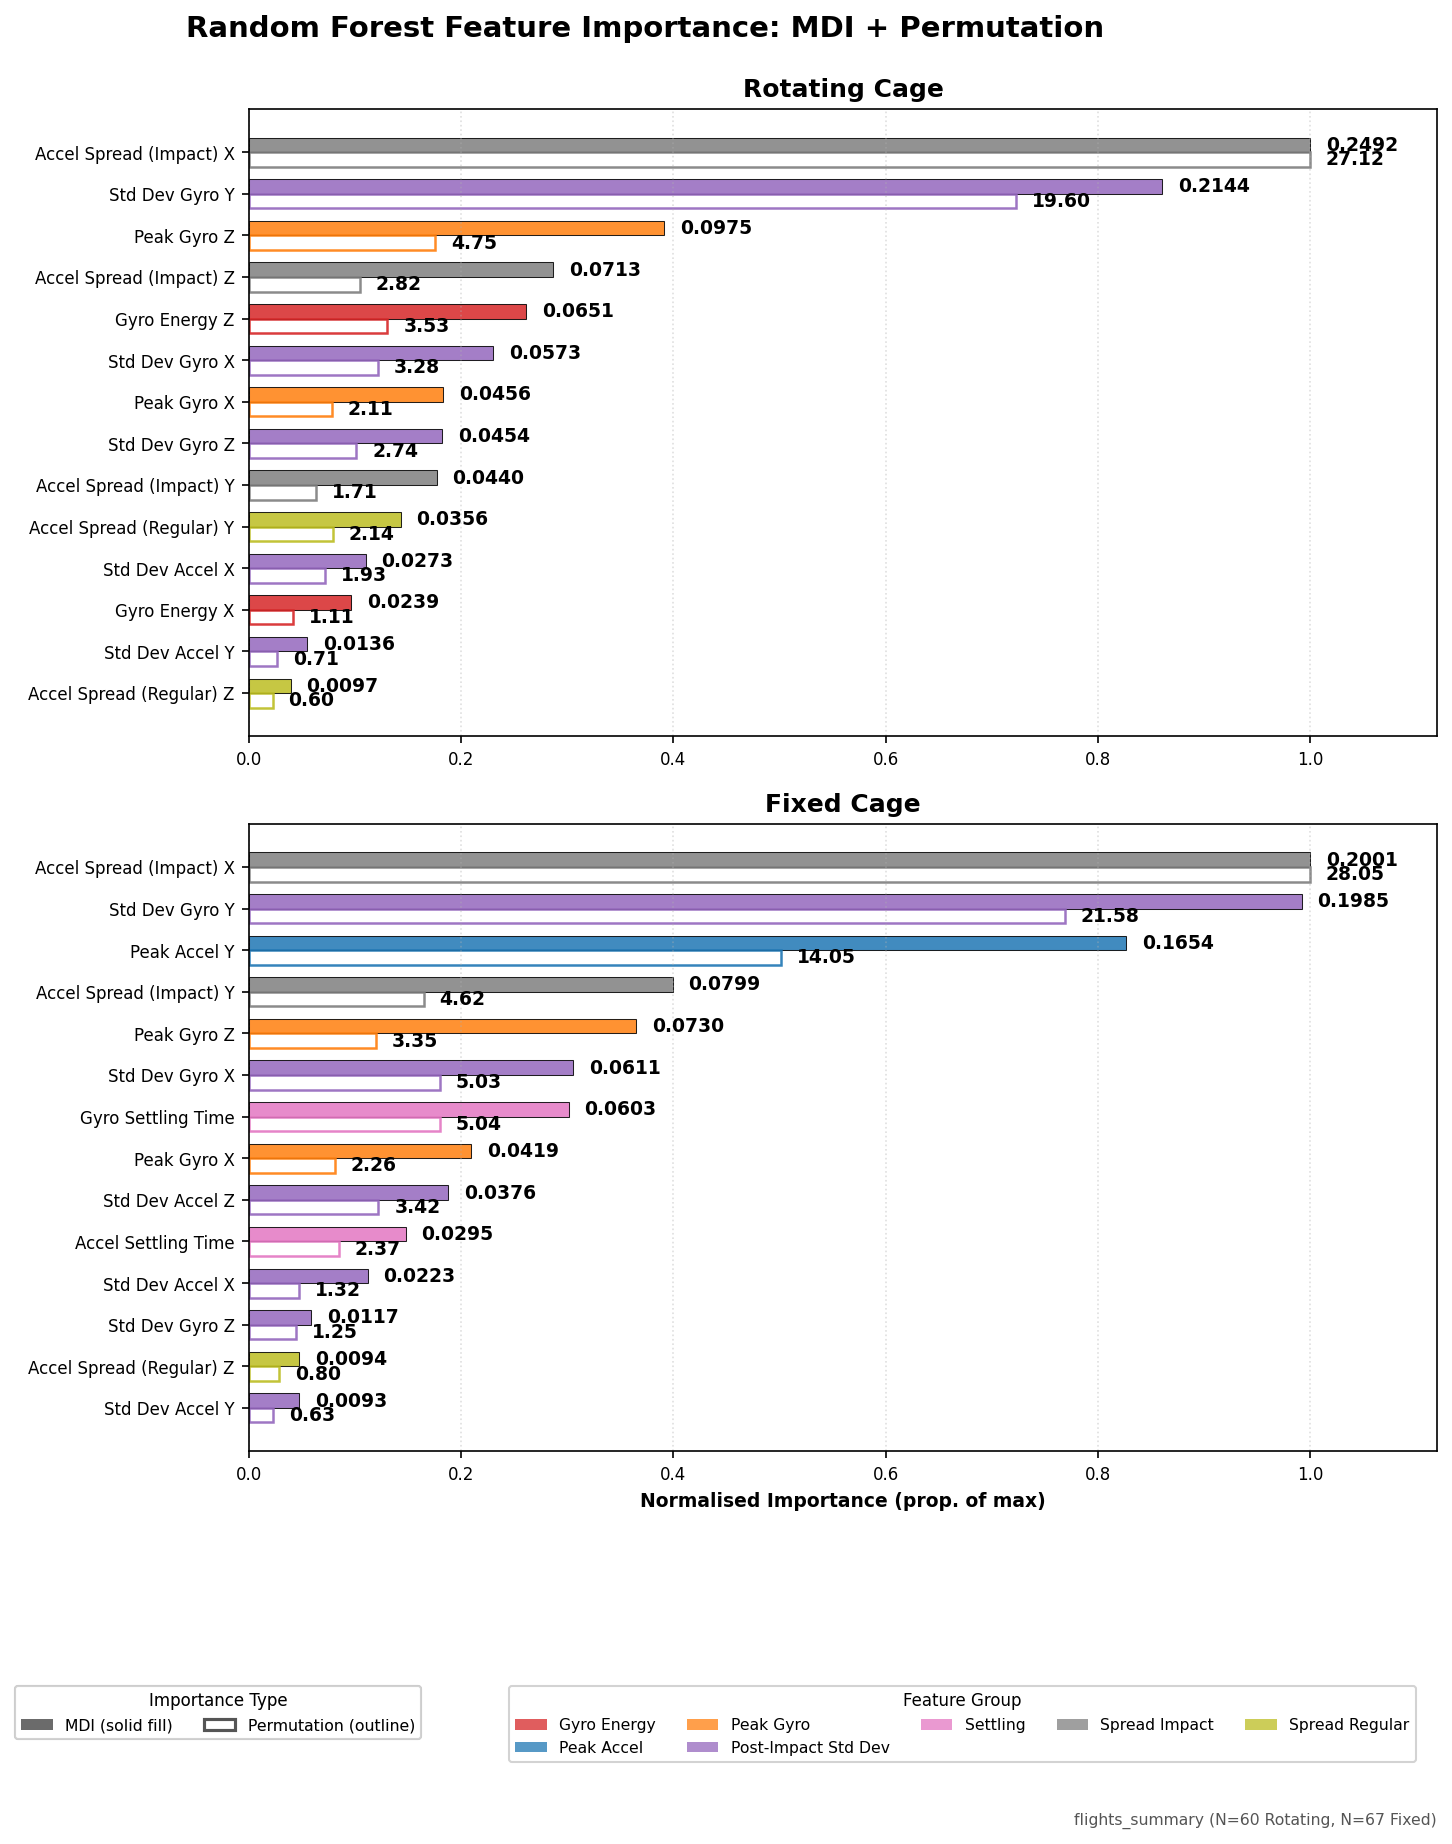

In [11]:
# ── Consolidated Feature Importance (Random Forest) ──
# Requires results_fix and results_rot from the RF pipeline cells above.
from dev_logs.analysis.models.rf_angle_prediction import (
    plot_consolidated_feature_importance,
)

if results_fix is not None and results_rot is not None:
    plot_consolidated_feature_importance(
        results_fix, results_rot,
        save_to_disk=True, show_plots=True,
    )
else:
    print("⚠️  Need both results_fix and results_rot — re-run RF pipeline cells above.")


### Key Observations — Feature Importance

1. **MDI and Permutation importance agree on the top features.** `Accel Spread (Impact) X` and `Vibration Gyro Y` dominate both panels. When two independent importance metrics (one tree-internal, one by data permutation) converge on the same features, the result is robust — not an artifact of the measurement method.

2. **Spread metrics > Peak metrics.** The RF confirms what the EDA correlation hinted: how *variable* the acceleration is during impact (spread) matters more than the maximum instantaneous value (peak). The impact *character* dominates the impact *magnitude*.

3. **Rotating Cage importance is more distributed.** In the Rotating condition, importance is spread across more features with smaller individual contributions. The spinning cage creates a more complex physical signature that no single IMU axis can dominate.

4. **Fixed Cage MDI is more concentrated.** A few features capture most of the predictive power — the simpler physics of the fixed condition means fewer IMU axes are needed to characterize the impact.

## 8. Consolidated Comparison Figures

All 4 comparison plot types are now rendered in single figures with **Fixed Cage on the left** and **Rotating Cage on the right**, using identical axis limits, ticks, and aspect ratios for direct visual comparison.

| Figure | Left Panel | Right Panel |
|--------|-----------|-------------|
| Actual vs Predicted | Fixed Cage 5-Fold CV | Rotating Cage 5-Fold CV |
| Residuals | Fixed Cage residuals | Rotating Cage residuals |
| Model Comparison | Fixed Cage Huber vs RF | Rotating Cage Huber vs RF |
| Learning Curves | Fixed Cage learning curve | Rotating Cage learning curve |

All plots: X/Y limits [0°, 90°] (predicted vs actual), ticks every 15°, aspect ratio = 1:1, legend outside plot box. Residuals Y: [−45°, 45°] with prominent zero line.


📊 Generating Consolidated Comparison Figures

1/6  Actual vs Predicted (Rotating × Fixed)


   💾 Saved → ../graphics/consolidated_actual_vs_predicted.png


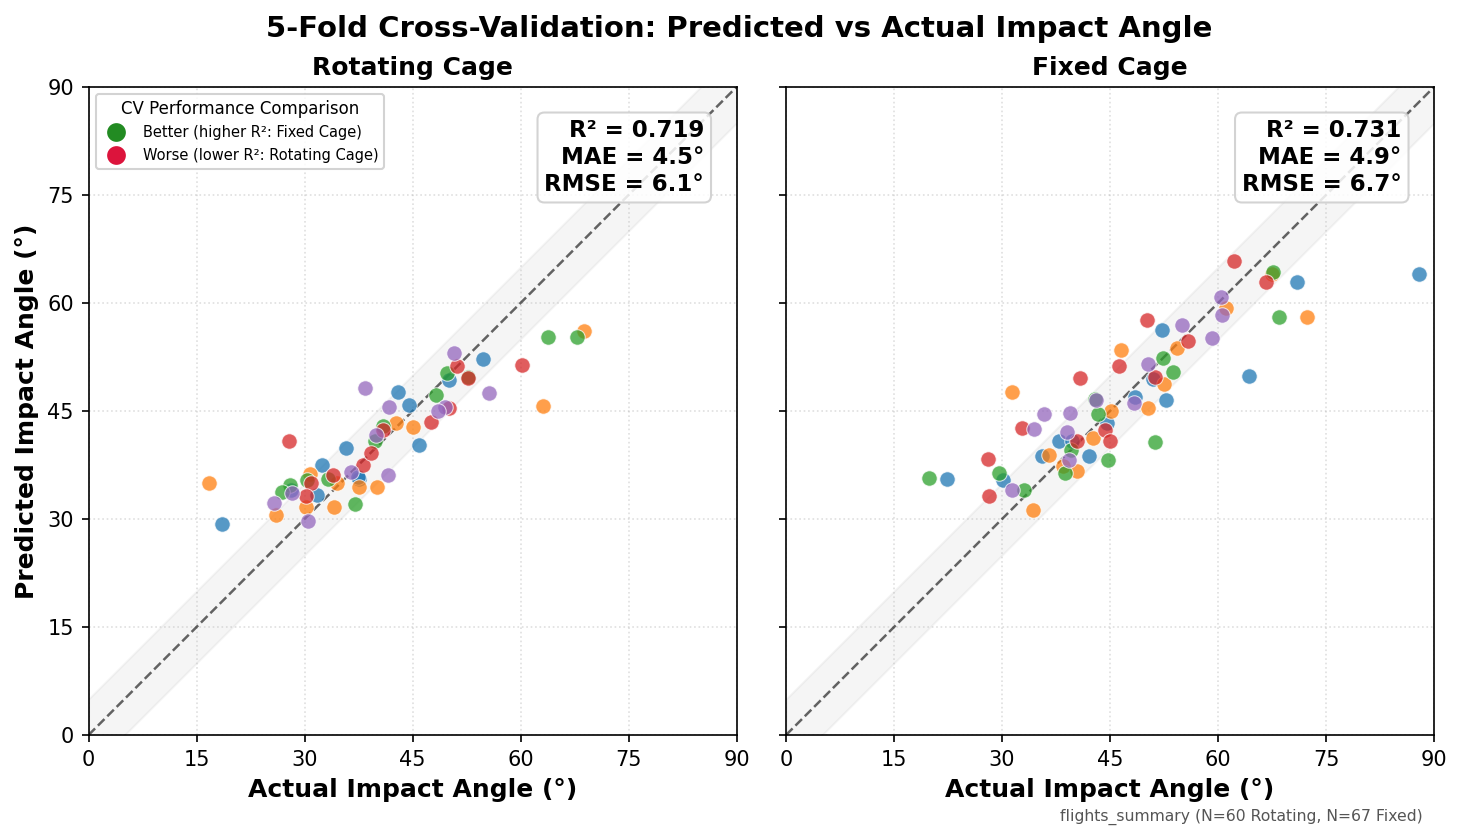


2/6  Residuals (Rotating × Fixed)


   💾 Saved → ../graphics/consolidated_residuals.png


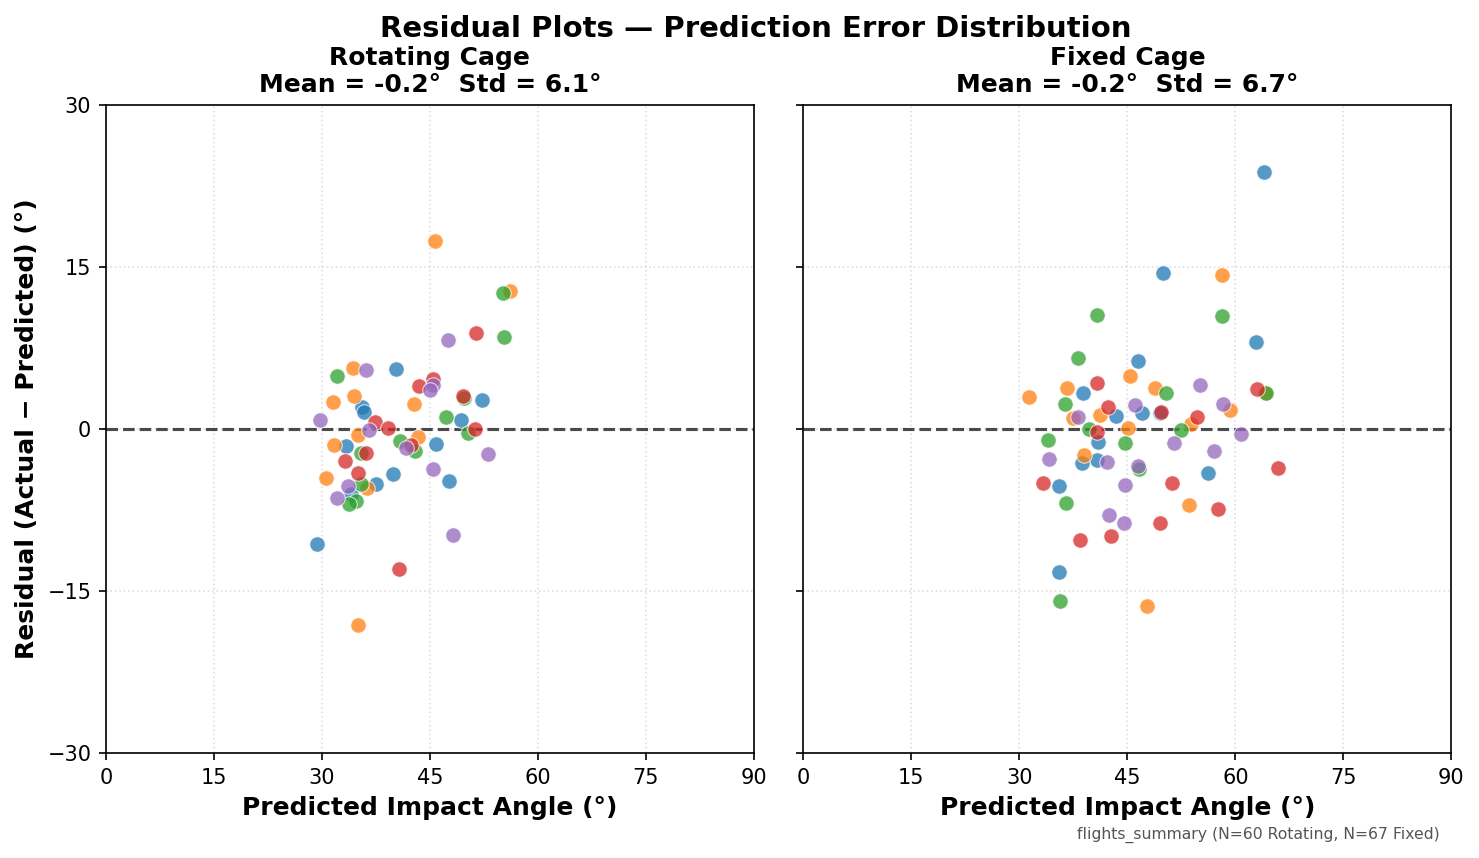


3/6  Model Comparison — Huber vs RF (Rotating × Fixed)


   💾 Saved → ../graphics/consolidated_model_comparison.png


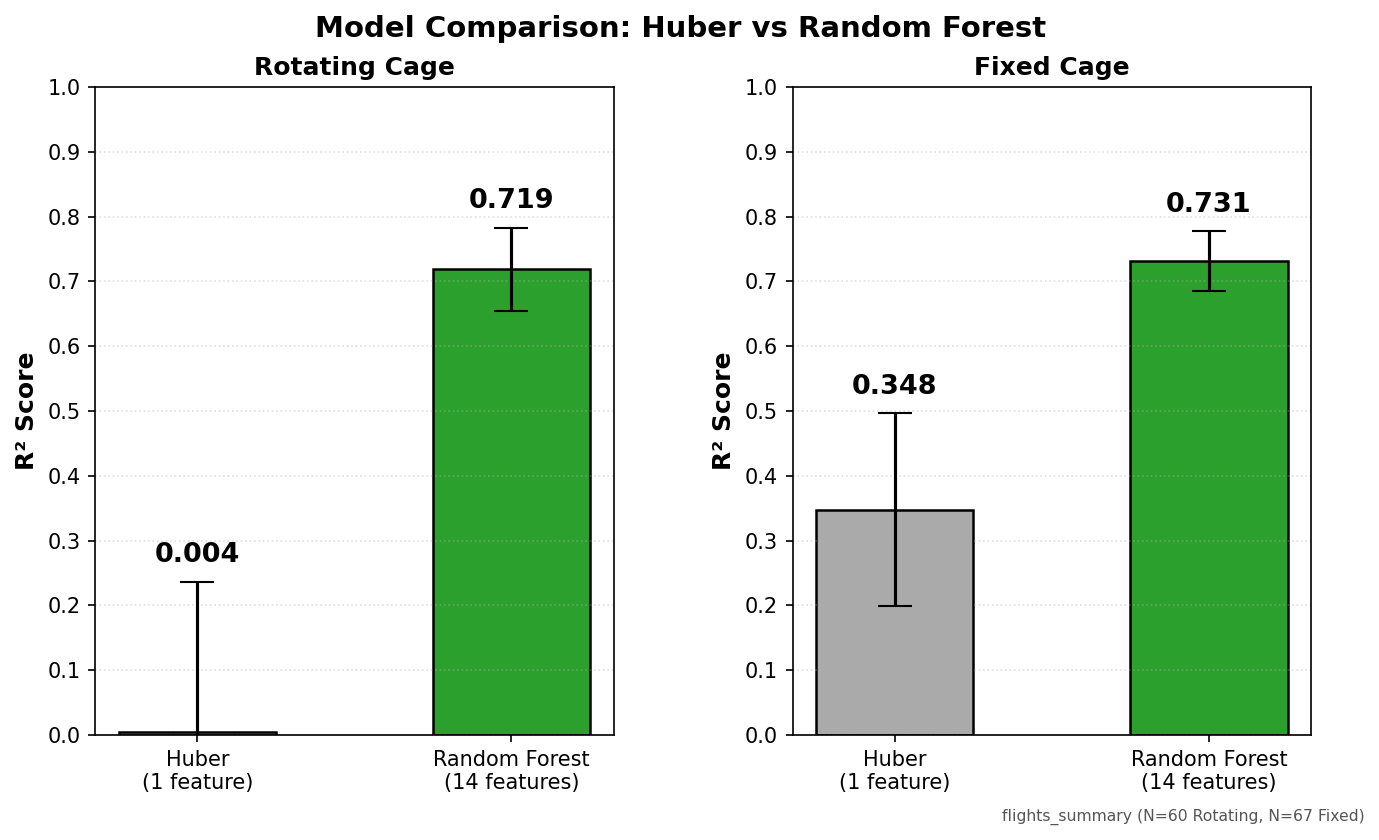


4/6  Learning Curves (Rotating × Fixed)


   💾 Saved → ../graphics/consolidated_learning_curves.png


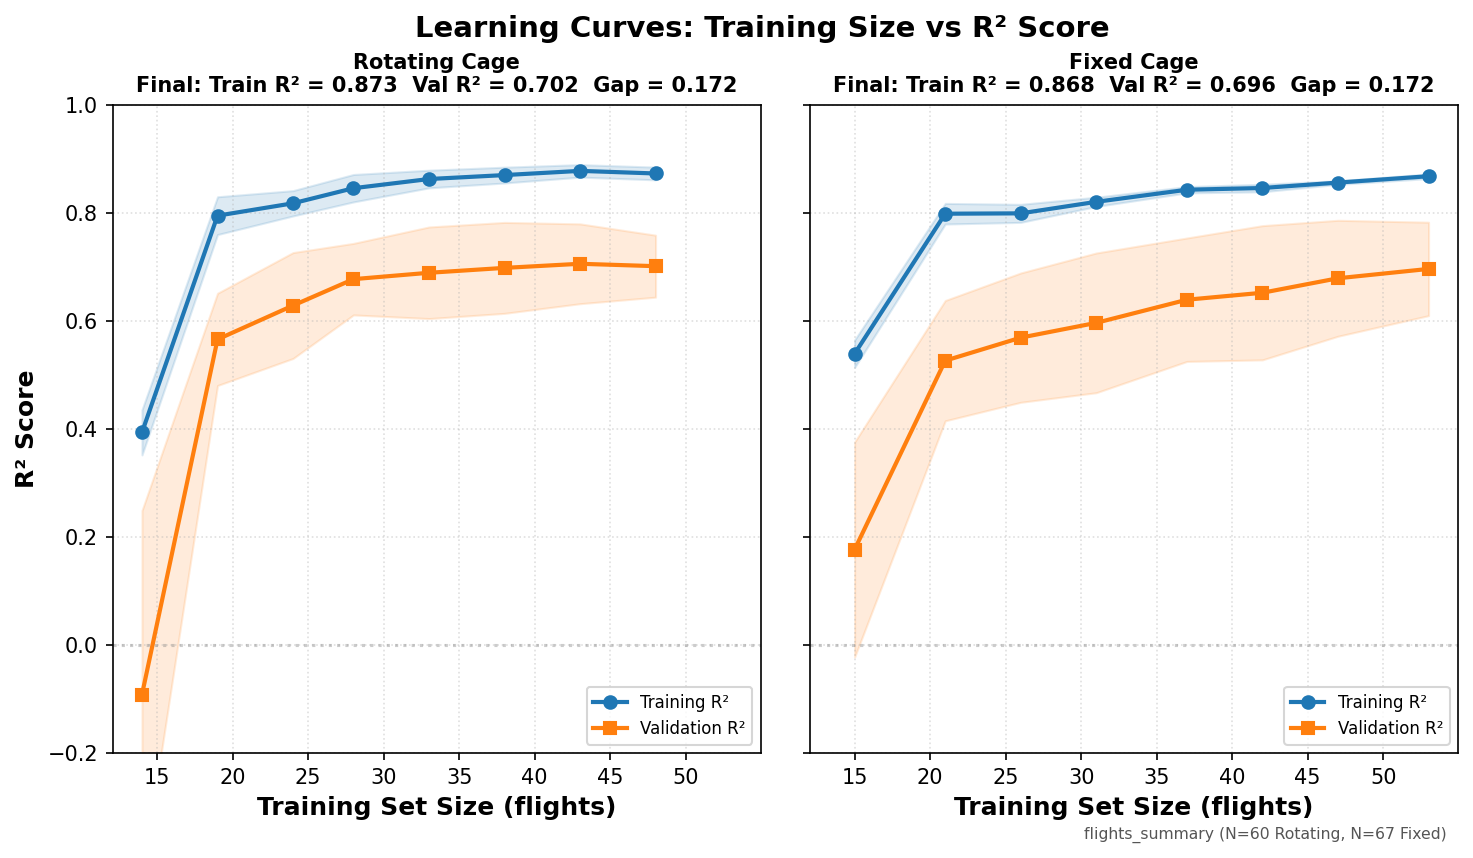


5/6  Feature Importance (Rotating × Fixed)


   💾 Saved consolidated feature importance → ../graphics/consolidated_feature_importance.png


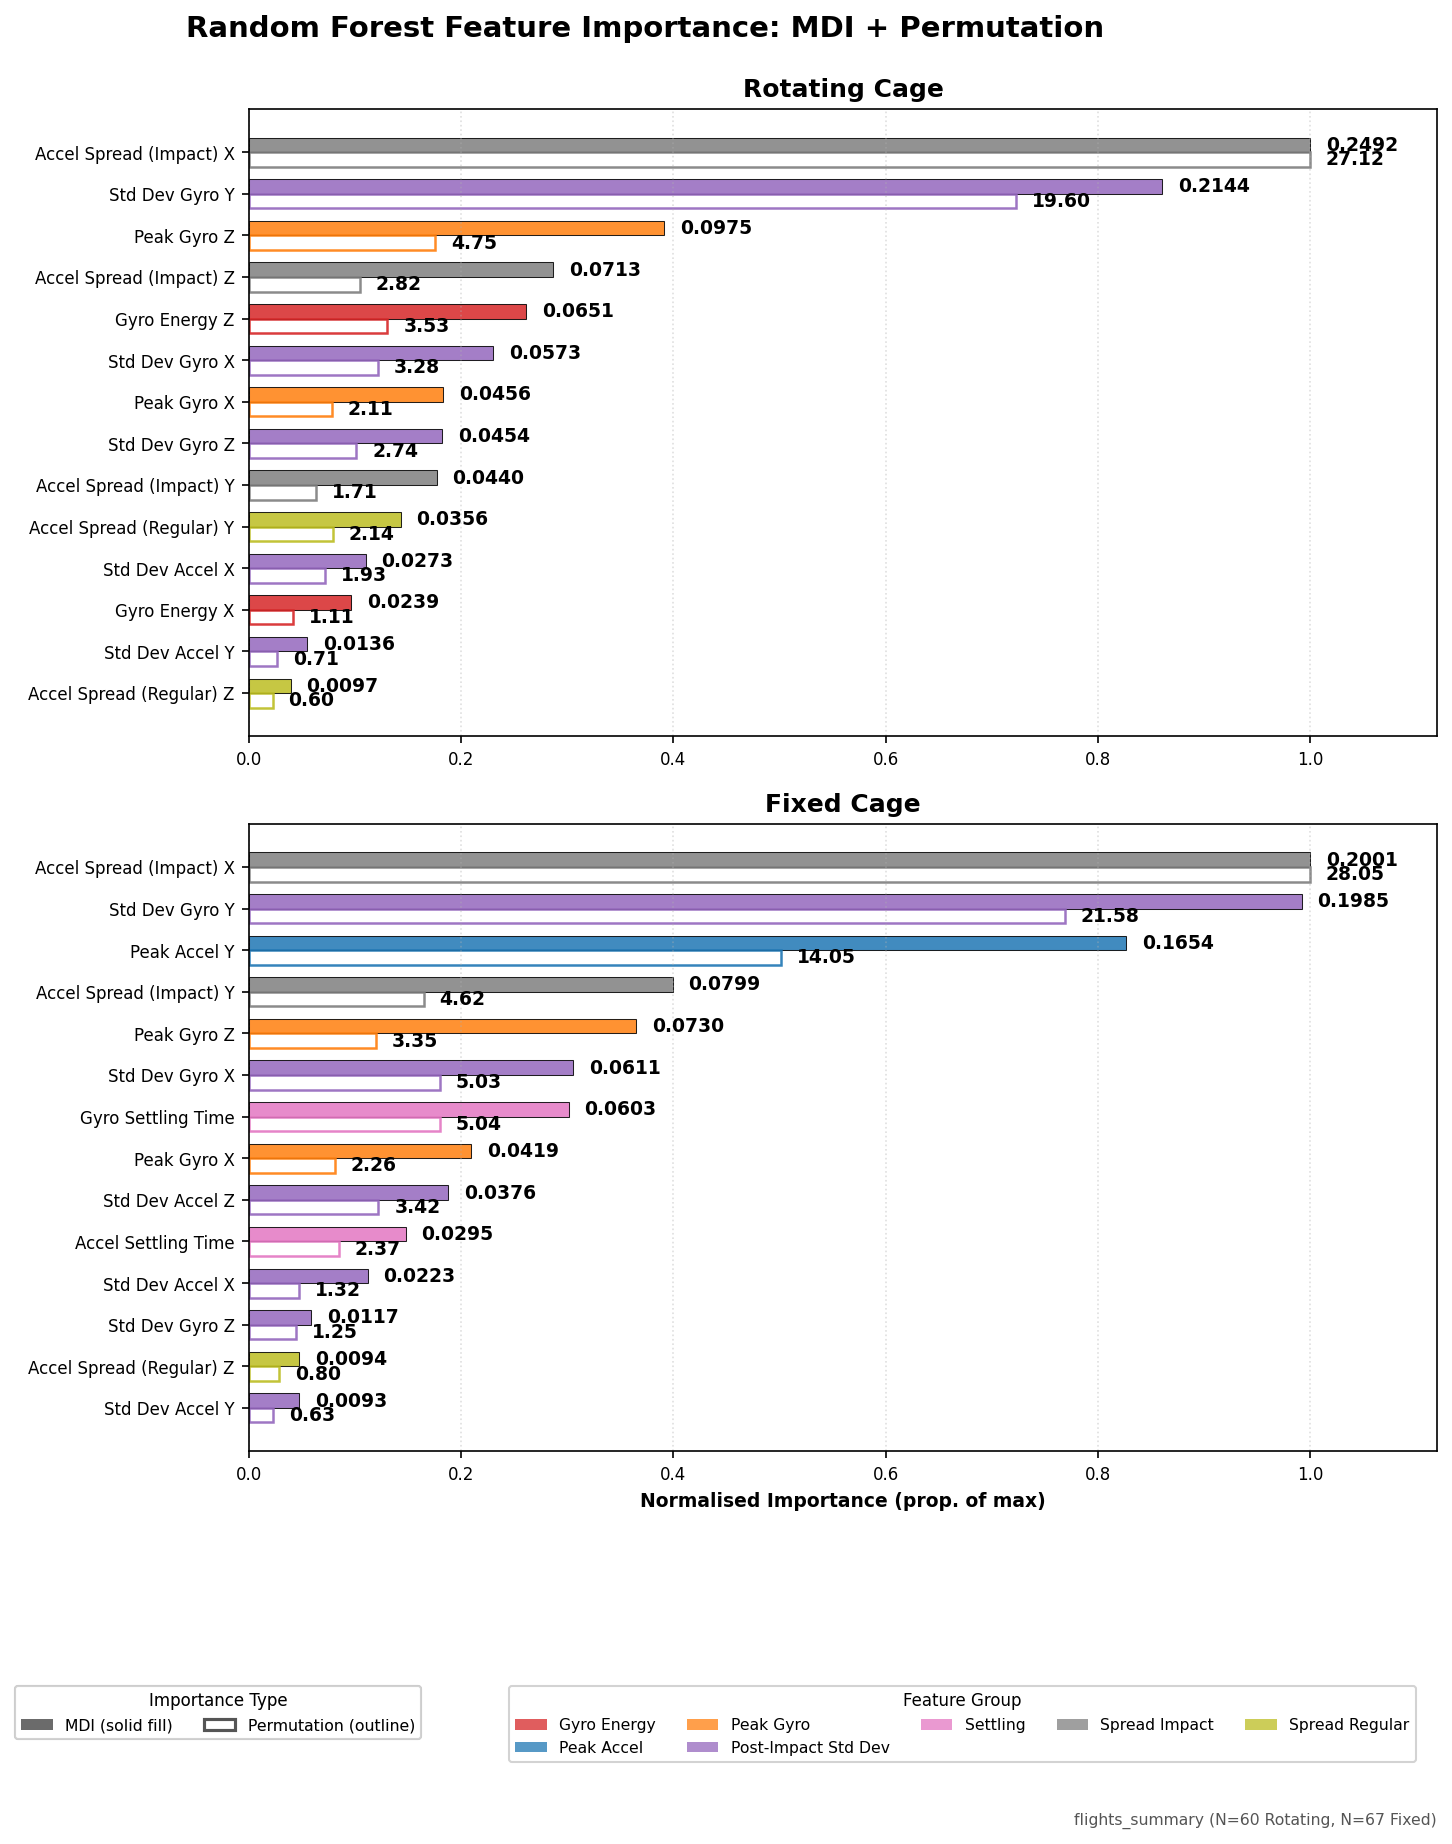


6/6  Cross Condition Transfer (both directions)


   💾 Saved consolidated cross-condition transfer → ../graphics/consolidated_cross_condition_transfer.png


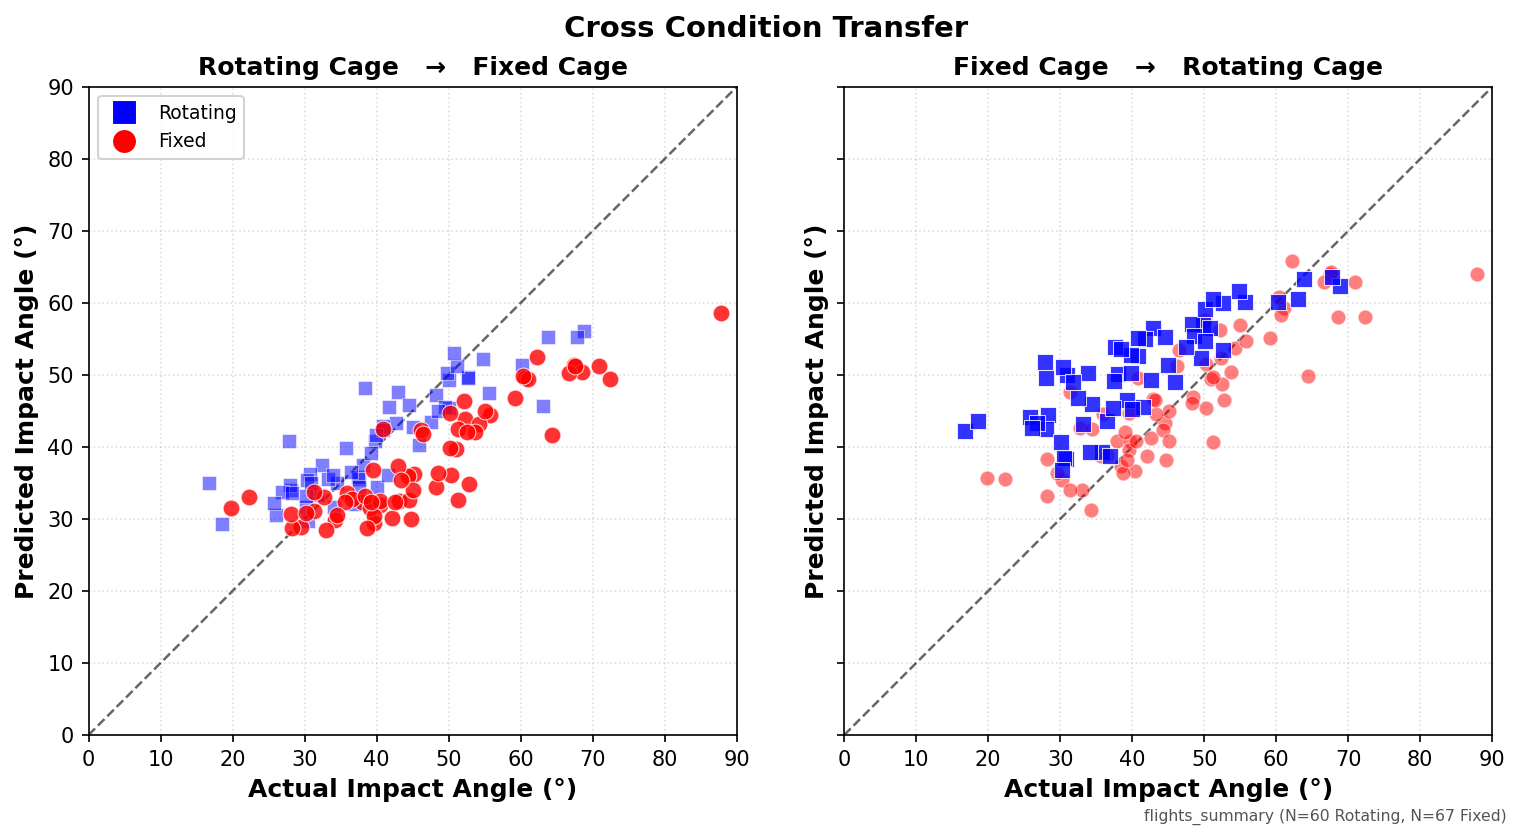


✅ All 6 consolidated figures → ../graphics/
   📎 → thesis/plots/consolidated_actual_vs_predicted.png
   📎 → thesis/plots/consolidated_residuals.png
   📎 → thesis/plots/consolidated_model_comparison.png
   📎 → thesis/plots/consolidated_learning_curves.png
   📎 → thesis/plots/consolidated_feature_importance.png
   📎 → thesis/plots/consolidated_cross_condition_transfer.png
✅ Thesis copies → /home/dorten/MasterThesisDrone/thesis/plots/


In [12]:
# ── Generate all 4 consolidated comparison figures ────────────────
generate_consolidated_plots(results_fix, results_rot,
                             save_to_disk=True, show_plots=True)

### Key Takeaways — Comparison Figures

1. **Predicted vs Actual (§8.1):** Both cages achieve R² > 0.70, but the scatter around the diagonal reveals different error patterns. Fixed Cage predictions hug the y=x line more tightly in the mid-range (30–60°); Rotating Cage errors are more evenly distributed.

2. **Residuals (§8.2):** No systematic U-shape or trend in either condition — the model is not biased toward overpredicting shallow angles or underpredicting steep ones. The ±5° band captures most CV predictions.

3. **Model Comparison (§8.3):** The RF demolishes the Huber baseline in both conditions, but the gap is larger for Rotating Cage (ΔR² ≈ +0.71) than Fixed (ΔR² ≈ +0.38). The rotating condition's more complex physics benefit more from multi-feature non-linear modeling.

4. **Learning Curves (§8.4):** Both curves trend upward — neither model has saturated. More training flights would likely improve R² further in both conditions.

5. **Cross-Condition Transfer (§8.5):** Fixed→Rotating transfer yields R² ≈ −0.10 (worse than mean). Rotating→Fixed transfer yields R² ≈ +0.26 (better than mean but far below within-condition CV). Both directions confirm: the two cage types produce fundamentally different IMU fingerprints. They must be modeled separately.